In [1]:
source("/rd1/user/lit/project/sORFs/sORFs.utils.R")
source("~/bin/lit_utils.R")
lib_text()
lib_plot()

In [32]:
output_path <- "../results/S4/"
create_path(output_path)

In [3]:
# 函数
merge_replicate <- function(df){
    # 合并重复
    df$Sample_merge_replicate <- gsub("21pcw(_1|_2|_3)", "21pcw", df$Sample)
    df %>% mutate(Sample=NULL) %>% rename(Sample=Sample_merge_replicate) -> df_1
    return(df_1)
}

# 数据过滤和整理

In [4]:
sample_metadata_path="../results/S1/sample_metadata_ordered.txt"
psm_sep_all_path <- "../results/S3/psm_sep_all.txt"

In [5]:
fread_c(sample_metadata_path) -> sample_metadata
# 对样本进行过滤
sample_metadata %>% filter(Replicate!=4)  %>% filter(Eyzyme!='Null') -> sample_metadata
fread_c(psm_sep_all_path) -> psm_sep_all
psm_sep_all %>% filter(PSM_type=="Unique") -> psm_sep_unique
# 对样本进行过滤
psm_sep_unique %>% filter(!grepl("4_PCP",psm_sep_unique$Sample) & !grepl("less3K",psm_sep_unique$Sample)) -> psm_sep_unique
psm_sep_unique %>% distinct(Protein,Sample) -> all_sample_sep
all_sample_sep %>% merge(sample_metadata,by = "Sample") -> all_sample_sep_m_meta
all_sample_sep_m_meta %>% arrange(Enrichment,Eyzyme,Replicate) -> all_sample_sep_m_meta

In [6]:
fwrite(all_sample_sep_m_meta,o("all_sample_sep_m_meta.txt"),sep='\t')

In [7]:
head(all_sample_sep_m_meta)
n_distinct(all_sample_sep_m_meta$Protein)

,Sample,Protein,Eyzyme,Period,Enrichment,Replicate,ms2_count
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>
1,21pcw_1_C8_T_T,sp|O75964|ATP5L_HUMAN,Trypsin,21pcw,C8,1,117437
2,21pcw_1_C8_T_T,sp|P42766|RL35_HUMAN,Trypsin,21pcw,C8,1,117437
3,21pcw_1_C8_T_T,sp|Q5U5X0|LYRM7_HUMAN,Trypsin,21pcw,C8,1,117437
4,21pcw_1_C8_T_T,sp|Q9Y3B4|SF3B6_HUMAN,Trypsin,21pcw,C8,1,117437
5,21pcw_1_C8_T_T,sp|Q9H299|SH3L3_HUMAN,Trypsin,21pcw,C8,1,117437
6,21pcw_1_C8_T_T,sp|P20674|COX5A_HUMAN,Trypsin,21pcw,C8,1,117437


[1] 2920

# 饱和曲线

## 合并重复之后的饱和曲线

In [8]:
merge_replicate(psm_sep_unique) -> df

In [13]:
output_path <- "../figures"
##### Saturation Plot #####
set.seed(123)
# sample_order <- sample(sample_metadata$Sample)
# sample_order <- sample_metadata %>% arrange(Enrichment,Eyzyme,Replicate) %>% .$Sample
sample_order <- merge_replicate(all_sample_sep_m_meta) %>% .$Sample %>% unique()
# 1. 蛋白累积分析（带柱状图）
res_protein <- cumu_combo_plot(
  df = df,
  sample_order = sample_order,
  target_col = "Protein",
  show_bar = TRUE
)
ggsave(res_protein$version_sampleNum,filename=o("cumu_pro_sample_n.pdf"),height = 5,width = 18)
ggsave(res_protein$version_sampleName,filename=o("cumu_pro_sample_name.pdf"),height = 5,width = 18)

# 2. 肽段累积分析（带柱状图）
res_peptide <- cumu_combo_plot(
  df = df,
  sample_order = sample_order,
  target_col = "Peptide",
  show_bar = TRUE
)
ggsave(res_peptide$version_sampleNum,filename=o("cumu_pep_sample_n.pdf"),height = 5,width = 18)
ggsave(res_peptide$version_sampleName,filename=o("cumu_pep_sample_name.pdf"),height = 5,width = 18)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


# 不同重复之间的overlap

In [11]:
cus_plot <- function(df){
    # 查看蛋白在一种富集方法一种酶切方法中重复被检测到的次数
    count(df,Protein,Eyzyme,Enrichment) %>% 
    group_by(Eyzyme,Enrichment) %>% 
    count(n) -> df_1
    library(ggplot2)
    ggplot(df_1, aes(x=factor(n), y=nn, fill=Eyzyme)) +
    geom_bar(stat='identity', position='dodge') +
      scale_fill_brewer(palette = "Set3") +
    facet_wrap(~Enrichment) +
    labs(x='Number of technical replicates (same enrichment & digestion condition)\nsupporting protein existence', y='Frequency')+
    theme_3() -> p
    return(p)
}

ERROR: Error in eval(expr, envir, enclos): 找不到对象'p'


In [12]:
all_sample_sep_m_meta %>% filter(grepl("^sp",Protein)) -> all_sample_sep_m_meta_cano
all_sample_sep_m_meta %>% filter(grepl("^ENST",Protein))  -> all_sample_sep_m_meta_uncano

In [13]:
all_sample_sep_m_meta_cano %>% count(Protein) %>% count(n) -> protein_detection_n_cano
protein_detection_n_cano$Type <- "Canonical"
all_sample_sep_m_meta_uncano %>% count(Protein) %>% count(n) -> protein_detection_n_uncano
protein_detection_n_uncano$Type <- "Uncanonical"
rbind(protein_detection_n_cano,protein_detection_n_uncano) -> protein_detection_n

Storing counts in `nn`, as `n` already present in input
ℹ Use `name = "new_name"` to pick a new name.
Storing counts in `nn`, as `n` already present in input
ℹ Use `name = "new_name"` to pick a new name.


In [14]:
protein_detection_n %>%
  mutate(
    Group = case_when(
      n == 1 ~ "Detection=1",
      n > 1  ~ "Detection>1"
    )
  )->tmp
head(tmp)
# 生成列联表
contingency_table <- tmp %>% group_by(Group,Type) %>% summarise(sum_nn=sum(nn)) %>% 
pivot_wider(values_from = sum_nn,names_from =Group ) %>% column_to_rownames("Type")
print("2x2列联表:")
print(contingency_table)

# 进行卡方检验
chi_test <- chisq.test(contingency_table)
print("\n卡方检验结果:")
print(chi_test)

,n,nn,Type,Group
,<int>,<int>,<chr>,<chr>
1,1,227,Canonical,Detection=1
2,2,42,Canonical,Detection>1
3,3,37,Canonical,Detection>1
4,4,24,Canonical,Detection>1
5,5,17,Canonical,Detection>1
6,6,13,Canonical,Detection>1


`summarise()` has grouped output by 'Group'. You can override using the
`.groups` argument.


[1] "2x2列联表:"
            Detection=1 Detection>1
Canonical           227         592
Uncanonical         713        1388
[1] "\n卡方检验结果:"

	Pearson's Chi-squared test with Yates' continuity correction

data:  contingency_table
X-squared = 10.16, df = 1, p-value = 0.001435



Warning message in brewer.pal(n = 2, name = "Set3"):
“minimal value for n is 3, returning requested palette with 3 different levels
”


[1] 0.7228327

[1] 0.6606378

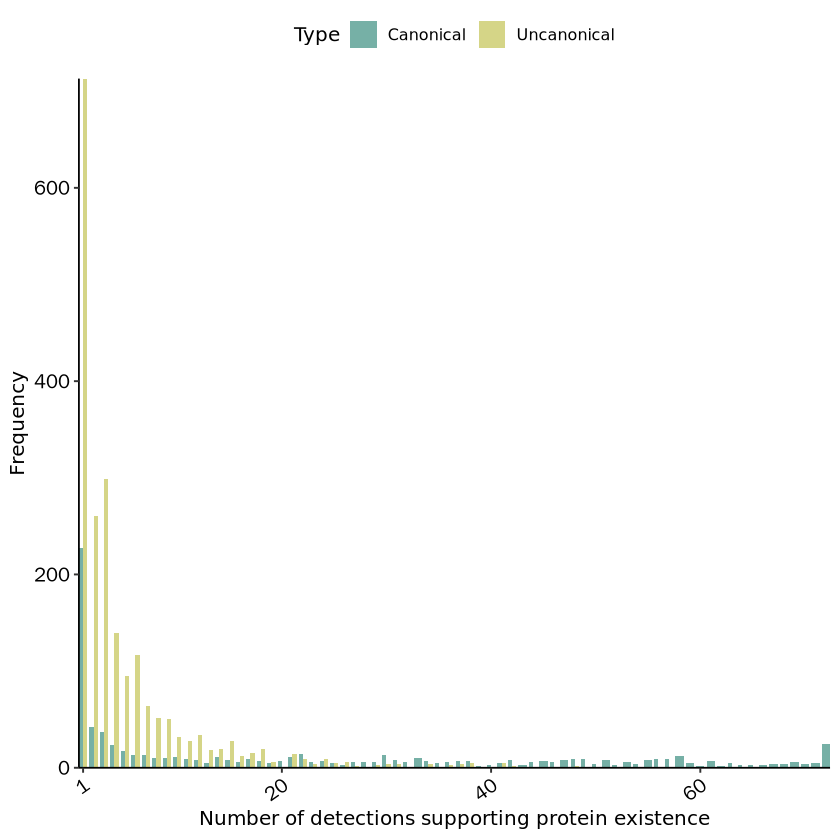

In [19]:
library(scales)
library(ComplexHeatmap)
library(circlize)
library(colorspace)
ggplot(protein_detection_n, aes_string(x = "n", y = "nn", fill = "Type")) + 
  geom_bar(stat = "identity", width = 0.8, position = position_dodge()) +
  scale_y_continuous(expand = c(0, 0)) +
scale_x_continuous(expand = c(0, 0),breaks = c(1, 20, 40, 60)) +
  theme_3(rotate = TRUE) +
  labs(fill = "Type") +
  scale_fill_manual(values = darken(brewer.pal(n = 2, name = "Set3"),amount = 0.15)) +
  labs(
    x = "Number of detections supporting protein existence",
    y = "Frequency"
  ) -> p
p
ggsave(p,filename=o("protein_detection_n.pdf"),height = 5,width = 8)
calcu_pro <- function(df){
    1-df$nn[1]/sum(df$nn)
}
calcu_pro(protein_detection_n_cano)
calcu_pro(protein_detection_n_uncano)

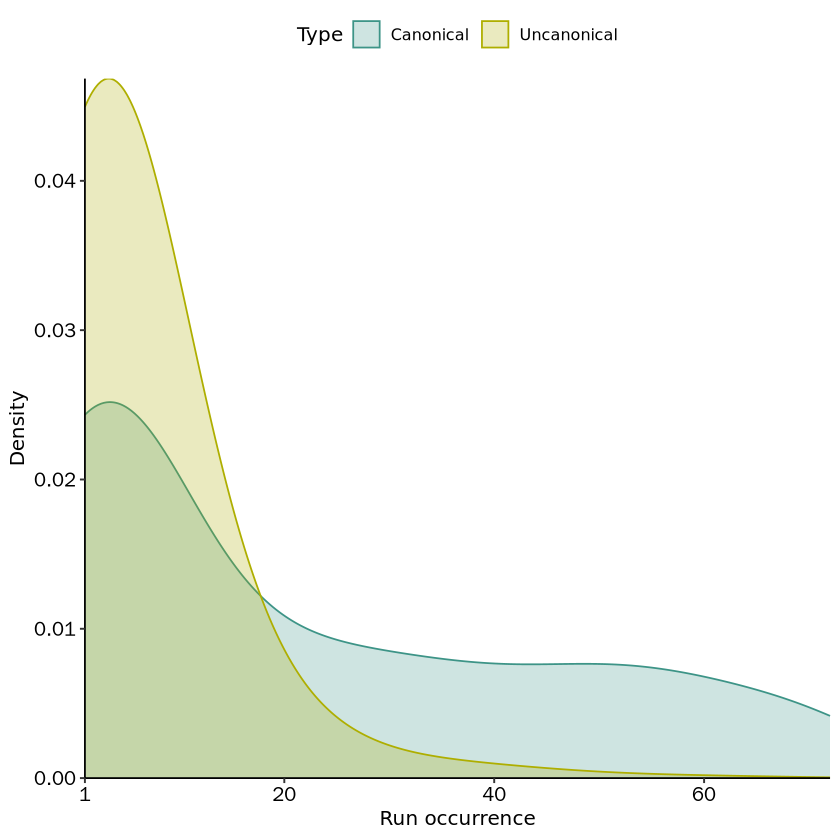

In [35]:
output_path <- "../figures"

library(RColorBrewer)
library(scales)

cols <- darken(brewer.pal(3, "Set3")[1:2], 0.3)
# cols <- desaturate(brewer.pal(3, "Set3")[1:2],-0.5)

p_dens <- ggplot(protein_detection_n,
                 aes(x = n, weight = nn, colour = Type, fill = Type)) +
  geom_density(alpha = 0.25, adjust = 1) +
  scale_y_continuous(expand = c(0, 0)) +
scale_x_continuous(expand = c(0, 0),breaks = c(1, 20, 40, 60)) +
  theme_3(rotate = FALSE) +
  scale_fill_manual(values = cols) +
  scale_colour_manual(values = cols) +
  labs(x = "Run occurrence",
       y = "Density", colour = "Type", fill = "Type")

p_dens
ggsave(filename = o("protein_detection_n_density.pdf"), plot = p_dens, height = 5, width = 8)


In [141]:
cus_plot(all_sample_sep_m_meta_cano) -> p
ggsave(p,filename=o("enrichmen_enzyme_tech_replicate_n_cano_protein.pdf"),height = 5,width = 8)
cus_plot(all_sample_sep_m_meta_uncano) -> p
ggsave(p,filename=o("enrichmen_enzyme_tech_replicate_n_uncano_protein.pdf"),height = 5,width = 8)

Storing counts in `nn`, as `n` already present in input
ℹ Use `name = "new_name"` to pick a new name.
Storing counts in `nn`, as `n` already present in input
ℹ Use `name = "new_name"` to pick a new name.


# 热图

In [47]:
merge_replicate <- function(df){
    # 合并重复
    df$Sample_merge_replicate <- gsub("21pcw(_1|_2|_3)", "21pcw", df$Sample)
    distinct(df,Protein,Sample_merge_replicate,Eyzyme,Enrichment) -> df_1
    df_1 %>% rename(Sample=Sample_merge_replicate) -> df_2
    return(df_2)
}
define_type <- function(x){
    return(if_else(grepl("^sp",x),"Cano","Uncano"))
}

Warning message in brewer.pal(length(unique(protein_stats$Type)), "Set3"):
“minimal value for n is 3, returning requested palette with 3 different levels
”


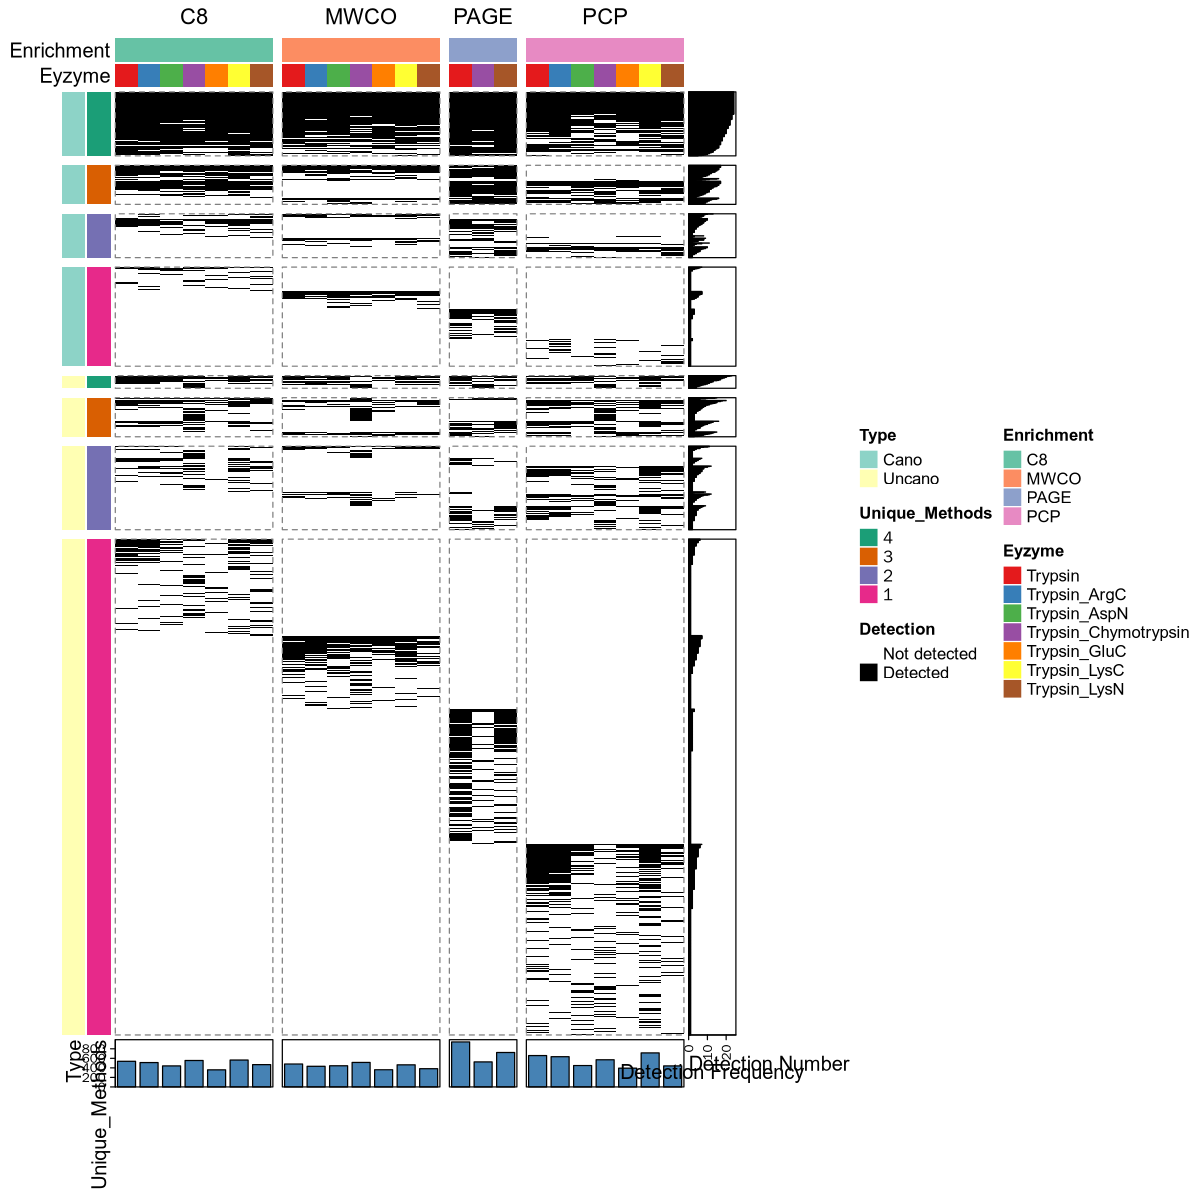

In [146]:
df <- merge_replicate(all_sample_sep_m_meta)
protein_stats <- df %>%
  group_by(Protein) %>%
  summarise(
    Unique_Methods = n_distinct(Enrichment),  # 被多少种不同富集方法鉴定到
    Total_Observations = n(),                 # 被鉴定到的总次数
    Supported_Enrichments = paste(sort(unique(Enrichment)), collapse = ", ")  # 支持的富集方法（去重后逗号分隔）
  )
protein_stats$Unique_Methods <- as.character(protein_stats$Unique_Methods)
protein_stats$Unique_Methods <- factor(protein_stats$Unique_Methods,levels=c('4','3','2','1'))
protein_stats$Type <- factor(define_type(protein_stats$Protein),levels = c("Cano","Uncano"))
protein_stats %>% arrange(Type,Unique_Methods, Supported_Enrichments,desc(Total_Observations)) -> protein_stats

library(ComplexHeatmap)
library(circlize)
# Create a binary detection matrix
binary_matrix_tmp <- df %>%
  mutate(present = 1) %>%
  select(Sample, Protein, present) %>%
  pivot_wider(names_from = Sample, values_from = present, values_fill = 0) %>%
  column_to_rownames("Protein") %>%
  as.matrix()
# 按照特定顺序排序
binary_matrix_tmp[protein_stats$Protein,] -> binary_matrix
# Calculate detection frequency for each protein
detection_freq <- rowSums(binary_matrix)
detection_number <- colSums(binary_matrix)

# Get unique sample annotations
sample_annot <- df %>%
  select(Sample,Enrichment,Eyzyme) %>%
  distinct() %>%
  column_to_rownames("Sample")

# Define colors for annotations
enzyme_colors <- setNames(brewer.pal(length(unique(sample_annot$Eyzyme)), "Set1"), 
                          unique(sample_annot$Eyzyme))
enrichment_colors <- setNames(brewer.pal(length(unique(sample_annot$Enrichment)), "Set2"), 
                              unique(sample_annot$Enrichment))
# Create column annotations
col_ha <- HeatmapAnnotation(
  df = sample_annot,
  col = list(
    Eyzyme = enzyme_colors,
    Enrichment = enrichment_colors
  ),
  annotation_name_side = "left"
)

# Create row annotation for detection frequency
row_ha <- rowAnnotation(
  "Detection Frequency" = anno_barplot(detection_freq, 
                                       bar_width = 0.8,
                                       gp = gpar(fill = "steelblue",col=NULL))
)
col_ha_1 <- columnAnnotation(
  "Detection Number" = anno_barplot(detection_number, 
                                       bar_width = 0.8,
                                       gp = gpar(fill = "steelblue",col=NULL))
)

# Define colors for annotations
type_colors <- setNames(brewer.pal(length(unique(protein_stats$Type)), "Set3"), 
                          unique(protein_stats$Type))
method_colors <- setNames(brewer.pal(length(unique(protein_stats$Unique_Methods)), "Dark2"), 
                              unique(protein_stats$Unique_Methods))
protein_stats[,c("Type","Unique_Methods")]  %>% as.data.frame() -> row_anno
rownames(row_anno) <- protein_stats$Protein
# Create column annotations
row_ha_1 <- rowAnnotation(
  df = row_anno,
  col = list(
    Type = type_colors[1:2],
    Unique_Methods = method_colors
  ),
  annotation_name_side = "bottom"
)

column_split <- factor(
  sample_annot$Enrichment, 
  levels = unique(sample_annot$Enrichment) 
)
groups <- paste0(protein_stats$Type,"-",protein_stats$Unique_Methods)
row_split <- factor(
    groups, 
    levels = unique(groups)
)

options(repr.plot.width = 10, repr.plot.height = 10)
ht <- Heatmap(
    binary_matrix,
    name = "Detection",
    col = c("white", "black"),
    cluster_columns = FALSE,
    clustering_distance_columns="binary",
    cluster_rows = FALSE,
    row_title=NULL,
    show_row_names = FALSE,
    show_column_names = FALSE,
    top_annotation = col_ha,
    right_annotation = row_ha,
    left_annotation = row_ha_1,
    bottom_annotation = col_ha_1,
    column_split = column_split,
    row_split = row_split,
    heatmap_legend_param = list(
        at = c(0, 1),
        labels = c("Not detected", "Detected")
    ),
    use_raster = FALSE,
    # 添加虚线分隔
    row_gap = unit(2, "mm"),
    column_gap = unit(2, "mm"),
    border_gp = gpar(lty = "dashed", col = "grey50")  # 替代方法
)
ht

In [147]:
# Draw the heatmap
# 1. 打开 PDF 设备，设置文件名和尺寸（单位：英寸）
pdf(o("protein_detection_heatmap.pdf"), width = 12, height = 12)
# 2. 绘制热图（假设 `ht` 是你的 Heatmap 对象）
draw(ht)
# 3. 关闭设备，保存文件
dev.off()

png 
  2

In [150]:
# 自动生成2x2列联表
library(dplyr)

# 创建分组变量
protein_stats_grouped <- protein_stats %>%
  mutate(
    Group = case_when(
      Unique_Methods == "1" ~ "Unique_Methods=1",
      Unique_Methods %in% c("2", "3", "4") ~ "Unique_Methods>1"
    )
  )

# 生成列联表
contingency_table <- table(protein_stats_grouped$Group, protein_stats_grouped$Type)
print("2x2列联表:")
print(contingency_table)

# 进行卡方检验
chi_test <- chisq.test(contingency_table)
print("\n卡方检验结果:")
print(chi_test)

# 检查期望频数
print("\n期望频数:")
print(chi_test$expected)

# 如果期望频数<5，使用Fisher精确检验
if(any(chi_test$expected < 5)) {
  print("\n期望频数<5，使用Fisher精确检验:")
  fisher_test <- fisher.test(contingency_table)
  print(fisher_test)
}

[1] "2x2列联表:"
                  
                   Cano Uncano
  Unique_Methods=1  330   1651
  Unique_Methods>1  489    450
[1] "\n卡方检验结果:"

	Pearson's Chi-squared test with Yates' continuity correction

data:  contingency_table
X-squared = 394.23, df = 1, p-value < 2.2e-16

[1] "\n期望频数:"
                  
                       Cano    Uncano
  Unique_Methods=1 555.6298 1425.3702
  Unique_Methods>1 263.3702  675.6298
